AAI-551 Final Project

Stevens Institute of Technology
Spring 2026
Professor Min Song

Team Members:
  - Jeff Busold (jlcbusold@icloud.com)
  - James Scott (james.p.scott@boeing.com)
  - Dominick Vovk (dvovk1015@gmail.com)

This Jupyter Notebook contains only the main program.  All other classes and functions
used are contained in subordinate .py files.

In [ ]:
"""
this is the main entry point for the AAI-551 Final Project code and is used to manage the
control flow used to orchestrate the loading of datasets, cleaning of datasets, and plotting
of datasets.  the main entry point is hosted in a Jupyter Notebook cell and can be executed
using the 'Run All' (Ctrl-Alt-Shift-Enter) from the Jupyter Notebook toolbar
"""

# import the global_internet_access module that encapsulates data lading, data cleaning, and
# plotting functions.
import global_internet_access

# Requirements (part 2) compliance:
#   2.7  __name__.  the entry point to the program employs the conventional guard when
#                   it imports or rns a module.
if __name__ == "__main__":
    """
    The main entry point for the AAI-551 Final Project code

    arguments: N/A

    returns: N/A
    """

    # load the global internet access dataset into a loader object
    loader = global_internet_access.load_global_internet_access_data()

    # clean the dataset just loaded, returning the cleaned pandas dataframe for plotting
    cleaned_df = global_internet_access.clean_global_internet_access_data()

    # plot the cleaned dataframe splitting the dataset across 'num_plots' different figures
    global_internet_access.plot_cleaned_internet_in_n_plots(cleaned_df, num_plots=6, value_col="dataValue", name_col="entityName")


## Digital Literacy & ICT Skills Analysis

**Team Member:** Jeff Busold  
**Focus Area:** Evaluate the impact of digital literacy and skills on the size and growth rate of the Digital Divide

This section analyzes ITU data across five ICT skill categories:
- Information and Data Literacy
- Communication and Collaboration
- Digital Content Creation
- Problem Solving
- Safety

The analysis identifies countries with measurable skill gaps, compares proficiency across categories and demographics, and tracks skill trends over time.

In [ ]:
from digital_skills.digital_skills_analysis import (
    run_digital_literacy_analysis
)

# run the full pipeline — loads all 5 ITU skill-category datasets, computes
# summary statistics, and identifies countries with skill gaps below 40%
results = run_digital_literacy_analysis()


### ICT Skill Gap Countries

The table below lists all countries identified as having a mean ICT skill proficiency below 40% across all five categories. These represent the nations most affected by digital literacy deficits.

In [ ]:
gap_countries = results["gap_countries"]
print(f"{len(gap_countries)} countries identified with mean skill proficiency below 40%:\n")
print(", ".join(gap_countries))


### Global ICT Skill Distribution

The chart below shows the top 10 and bottom 10 countries by mean ICT skill proficiency across all five categories for a selected year. This highlights the breadth of the global skill divide.

In [ ]:
import matplotlib.pyplot as plt

analyzer = results["analyzer"]

# plot top/bottom 10 countries by mean skill proficiency across all categories
fig = analyzer.plot_global_skill_distribution(2020)
plt.show()


### ICT Skill Level Comparison

The tables below compares the average percentage of the population with basic skills in each category versus the percentage of the population with above basic skills. The sample countries used are Denmark (DNK) and Ukraine (UKR), taken from the top and bottom of the global rankings seen above. This illustrates the disparity in skill levels both within and between countries.

In [ ]:
dnk_skill_growth = analyzer.plot_skill_growth("DNK")
print(dnk_skill_growth)

In [ ]:
ukr_skill_growth = analyzer.plot_skill_growth("UKR")
print(ukr_skill_growth)

### ICT Skill Rate Forecast — PyTorch Predictor

The `DigitalLiteracyPredictor` trains a small multi-layer perceptron (MLP) on each country’s historical total-population ICT skill rates and projects values into future years. One model is fitted per skill category, using Adam optimisation with year normalisation to ensure stable convergence on the short ITU time-series (typically 5–20 observations per country).

The table below shows five-year forecasts for Denmark and Ukraine, representing a high-skill and low-skill country respectively. The projections indicate whether the skill gap is expected to widen or narrow in the coming years.

In [ ]:
from digital_skills import DigitalLiteracyPredictor

predictor = DigitalLiteracyPredictor(analyzer)

dnk_forecast = predictor.plot_predicted_growth("DNK", years_ahead=5)
plt.show()

In [ ]:
ukr_forecast = predictor.plot_predicted_growth("UKR", years_ahead=5)
plt.show()

## Mobile Internet Price Regulation Analysis

**Team Member:** Dominick Vovk  
**Focus Area:** Evaluate the impact of affordability and mobile internet/data price regulation on the Digital Divide

This section analyzes ITU mobile services data related to price regulation of retail Internet access and data services, where the goal is to determine whether countries with price control policies show different internet usage levels compared to countries without price control. This connects to the Digital Divide because affordability is one of the major barriers that can prevent people from accessing online services, digital education, and communication tools.

In [2]:
from price_regulation.price_regulation_analysis import run_price_regulation_analysis

price_results = run_price_regulation_analysis(
    price_file="mobile-services_1778017040787.csv",
    internet_file="individuals-using-the-internet.csv",
    data_dir="datasets"
)

Running Mobile Internet Price Regulation Analysis
PriceRegulationDataset(rows=1783, series='Price regulation of retail Internet access and data services')
PriceRegulationAnalyzer(countries=187)

Summary Statistics:
countries_compared: 187
with_price_control: 61
without_price_control: 126
percent_with_price_control: 32.62
avg_internet_with_control: 53.67
avg_internet_without_control: 77.36
average_difference: -23.69

Low internet usage countries without price control: 20


### Summary Statistics

The summary statistics below compare countries with mobile internet/data price control against countries without price control and the results show how many countries fall into each group and the average internet usage percentage for each regulation status.

In [3]:
price_results["stats"]

{'countries_compared': 187,
 'with_price_control': 61,
 'without_price_control': 126,
 'percent_with_price_control': 32.62,
 'avg_internet_with_control': 53.67,
 'avg_internet_without_control': 77.36,
 'average_difference': -23.69}

### Price Regulation Status by Country Count

The chart below shows how many countries have price control compared to how many countries do not have price control for retail Internet access and data services, giving us a basic view of how common price regulation is across the countries included in the dataset.

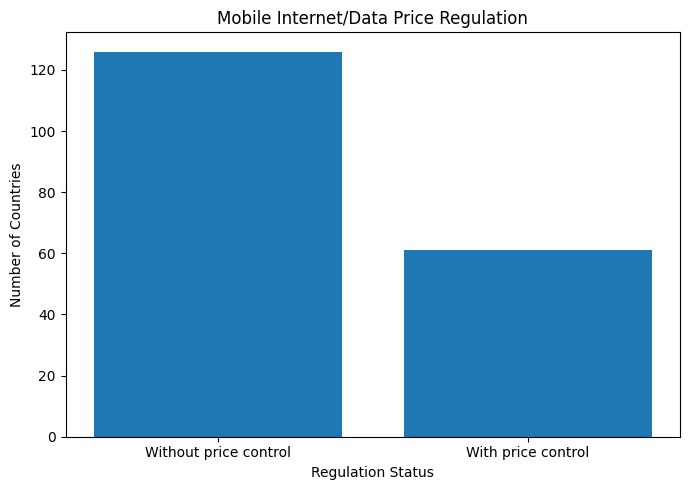

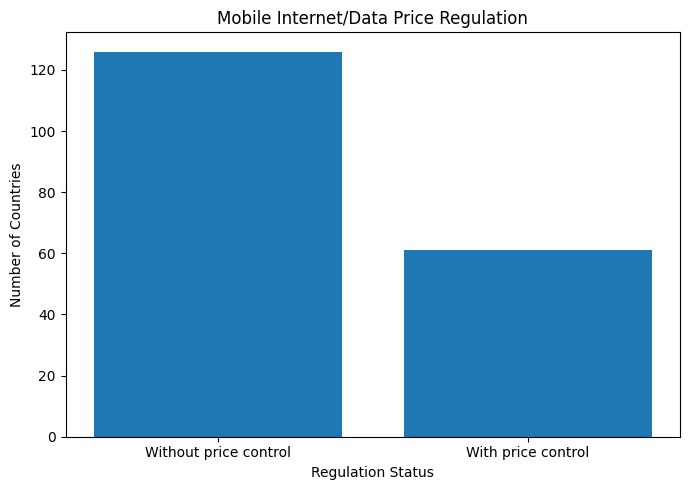

In [5]:
price_results["analyzer"].plot_regulation_counts()

### Average Internet Usage by Price Regulation Status

The chart below compares the average internet usage percentage for countries with price control and countries without price control, comparing helps evaluate whether price regulation is associated with different internet access levels across countries.

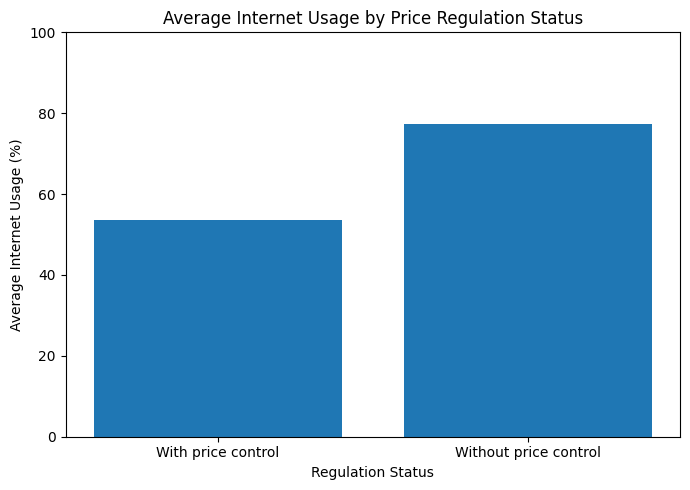

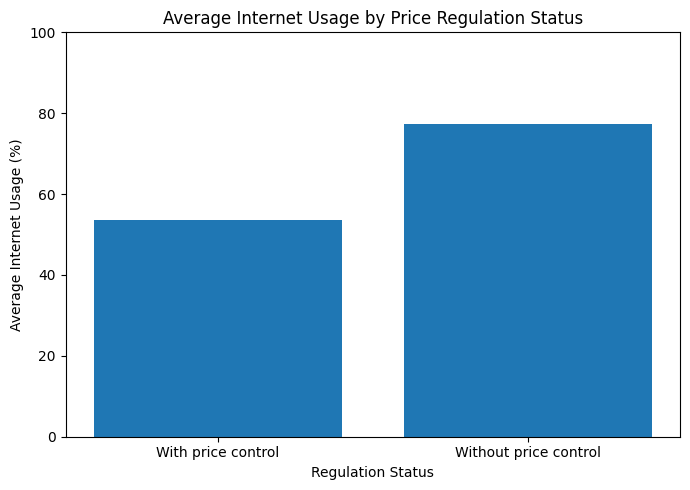

In [6]:
price_results["analyzer"].plot_average_internet_usage()

### Low Internet Usage Countries Without Price Control

The table below lists countries that have internet usage below 60% and do not have price control for retail Internet access and data services, where these countries may represent areas where affordability and access barriers are more visible.

In [7]:
price_results["low_access_without_control"].head(20)

,seriesName,entityIso,entityName,dataValue,dataYear,price_control,internet_usage,internet_year
0,Price regulation of retail Internet access and...,NER,Niger,Without price control,2014,0,15.557600,2024
1,Price regulation of retail Internet access and...,ZMB,Zambia,Without price control,2024,0,17.101000,2024
2,Price regulation of retail Internet access and...,MDG,Madagascar,Without price control,2024,0,18.677900,2024
3,Price regulation of retail Internet access and...,PNG,Papua New Guinea,Without price control,2018,0,18.811600,2024
4,Price regulation of retail Internet access and...,MOZ,Mozambique,Without price control,2021,0,20.527300,2024
5,Price regulation of retail Internet access and...,WSM,Samoa,Without price control,2024,0,21.200001,2014
6,Price regulation of retail Internet access and...,VUT,Vanuatu,Without price control,2019,0,22.351400,2015
7,Price regulation of retail Internet access and...,SLE,Sierra Leone,Without price control,2022,0,25.105000,2024
8,Price regulation of retail Internet access and...,SOM,Somalia,Without price control,2024,0,27.940201,2024
9,Price regulation of retail Internet access and...,BFA,Burkina Faso,Without price control,2023,0,28.252701,2024


### Low Access Without Price Control Visualization

The chart below shows the lowest internet usage countries that do not have mobile internet/data price control, helping us identify countries where internet usage remains low and where affordability policy may be worth further investigation.

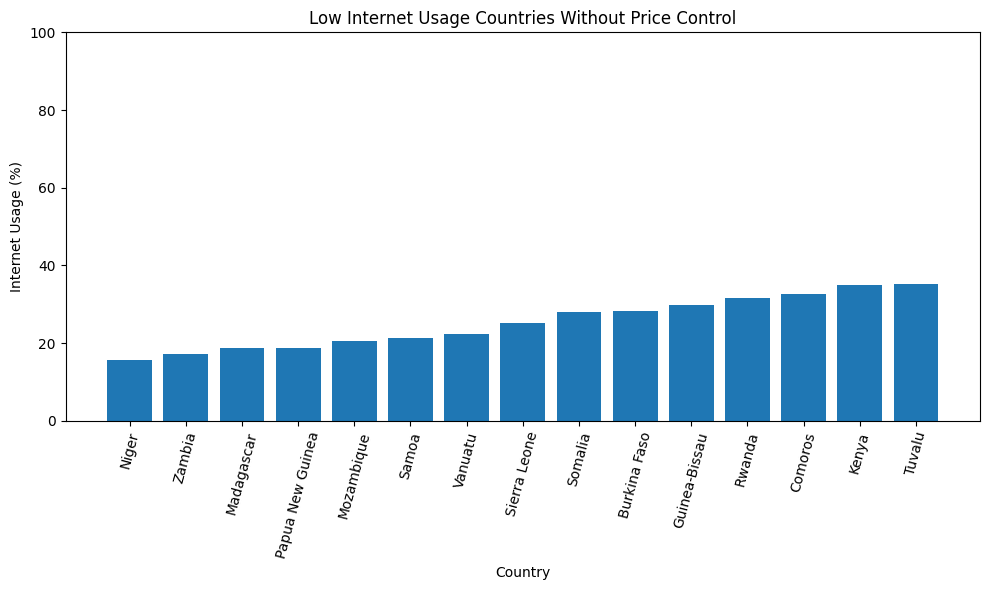

In [9]:
import matplotlib.pyplot as plt

price_results["analyzer"].plot_low_access_without_control(threshold=60.0, top_n=15)
plt.show()